# 🚀 Practice Day 22

**📅 Date:** 2026-10-03  
**📁 Category:** Phase 2 · SQL 중급(JOIN·서브쿼리·CASE WHEN) (Round 2/5)

---
# 🎯 Today's Goal
*What am I trying to solve today?*

- Practice JOIN, a subquery, and CASE WHEN in DuckDB SQL — the same vet clinic data as yesterday, solved a different way
  (DuckDB SQL의 JOIN·서브쿼리·CASE WHEN 연습 — 어제와 같은 동물병원 데이터를 다른 방식으로 풀어보기)
- Find which owner spends the most, which pets visit more often than average, and how visit costs break into price tiers
  (어떤 보호자가 가장 많이 지출하는지, 평균보다 자주 방문하는 반려동물은 누구인지, 진료비용이 구간별로 어떻게 나뉘는지 파악하기)

---
# 📂 Dataset

**Dataset Name:** Astoria Vet Clinic — same 3 tables as Day 21, solved with SQL this time / Astoria 동물병원 — 보호자·반려동물·진료기록 (Day 21과 동일 데이터, SQL로 재풀이)

**Source:** Synthetically generated for practice, same generation code as Day 21 / 실습을 위해 코드로 생성, Day 21과 동일한 생성 코드

**Description:** The same `owners` (60), `pets` (90), and `visits` (220, cost in USD) tables from yesterday's file. Owner cities are NYC neighborhoods. This time, instead of pandas merge, the focus is on answering similar questions using DuckDB SQL — JOIN across all three tables, a subquery, and CASE WHEN.
(어제(Day 21) 만든 것과 동일한 owners(60)·pets(90)·visits(220, 비용 USD) 3테이블입니다. 보호자 도시는 뉴욕 동네입니다. 이번에는 pandas merge 대신 duckdb.sql()의 JOIN(3테이블 전체 연결), 서브쿼리, CASE WHEN을 사용해 비슷한 질문에 답하는 데 초점을 둡니다.)

## Dataset Preview

In [1]:
# Dataset Preview
import pandas as pd
import numpy as np
from IPython.display import display

np.random.seed(42)
rng = np.random.default_rng(42)

# --- owners ---
first_names = ['Sarah', 'James', 'Maria', 'David', 'Emily', 'Michael', 'Laura', 'Kevin', 'Anna', 'Brian',
                'Nicole', 'Daniel', 'Rachel', 'Peter', 'Grace', 'Tom', 'Julia', 'Mark', 'Susan', 'Chris']
last_names = ['Kim', 'Park', 'Lee', 'Smith', 'Johnson', 'Garcia', 'Brown', 'Davis', 'Wilson', 'Martinez',
               'Taylor', 'Clark', 'Lewis', 'Walker', 'Hall']

n_owners = 60
owner_ids = [f'O{str(i).zfill(3)}' for i in range(1, n_owners + 1)]
owner_names = []
used = set()
while len(owner_names) < n_owners:
    name = f"{rng.choice(first_names)} {rng.choice(last_names)}"
    if name not in used:
        used.add(name)
        owner_names.append(name)
surname_map = {'Kim': 'Miller', 'Park': 'Anderson', 'Lee': 'Thomas'}
owner_names = [
    f"{first} {surname_map.get(last, last)}"
    for first, last in (name.split() for name in owner_names)
]


cities = ['Midtown', 'Williamsburg', 'Astoria', 'Chelsea', 'SoHo', 'Forest Hills']
owners = pd.DataFrame({
    'owner_id': owner_ids,
    'owner_name': owner_names,
    'city': rng.choice(cities, size=n_owners)
})

# --- pets (each owner has >=1 pet; 30 extra pets distributed randomly) ---
n_pets = 90
species_list = ['Dog', 'Cat', 'Bird', 'Rabbit', 'Reptile']
species_w = [0.45, 0.35, 0.08, 0.08, 0.04]
pet_name_pool = ['Max', 'Bella', 'Charlie', 'Luna', 'Cooper', 'Milo', 'Daisy', 'Rocky', 'Sadie', 'Buddy',
                  'Coco', 'Leo', 'Molly', 'Jack', 'Lucy', 'Oliver', 'Ruby', 'Teddy', 'Zoe', 'Duke',
                  'Chloe', 'Bear', 'Penny', 'Simba', 'Nala', 'Kiwi', 'Peanut', 'Shadow', 'Ginger', 'Biscuit']

owner_pet_counts = {oid: 1 for oid in owner_ids}
for oid in rng.choice(owner_ids, size=n_pets - n_owners, replace=True):
    owner_pet_counts[oid] += 1

pet_rows = []
pet_counter = 1
for oid, cnt in owner_pet_counts.items():
    for _ in range(cnt):
        pet_rows.append({
            'pet_id': f'P{str(pet_counter).zfill(3)}',
            'owner_id': oid,
            'pet_name': rng.choice(pet_name_pool),
            'species': rng.choice(species_list, p=species_w),
            'age': int(rng.integers(1, 15))
        })
        pet_counter += 1
pets = pd.DataFrame(pet_rows)

# --- visits (some pets visit much more often than others) ---
n_visits = 220
reasons = ['Checkup', 'Vaccination', 'Illness', 'Dental', 'Surgery', 'Emergency']
reason_w = [0.28, 0.22, 0.20, 0.10, 0.06, 0.14]
# visit cost in USD (45000 KRW -> $45)
avg_cost = {'Checkup': 45, 'Vaccination': 35, 'Illness': 85, 'Dental': 120, 'Surgery': 450, 'Emergency': 280}

pet_visit_weight = rng.gamma(shape=2.0, scale=1.0, size=n_pets)
pet_visit_p = pet_visit_weight / pet_visit_weight.sum()
visit_pet_ids = rng.choice(pets['pet_id'].values, size=n_visits, replace=True, p=pet_visit_p)
visit_dates = pd.to_datetime('2024-01-01') + pd.to_timedelta(rng.integers(0, 181, size=n_visits), unit='D')

visit_rows = []
for i in range(n_visits):
    reason = rng.choice(reasons, p=reason_w)
    cost = int(round(rng.normal(avg_cost[reason], avg_cost[reason] * 0.15)))  # whole dollars
    cost = max(10, cost)
    visit_rows.append({
        'visit_id': f'V{str(i+1).zfill(4)}',
        'pet_id': visit_pet_ids[i],
        'visit_date': visit_dates[i],
        'reason': reason,
        'cost': cost
    })
visits = pd.DataFrame(visit_rows).sort_values('visit_date').reset_index(drop=True)

print("Owners:")
display(owners.head())
print("\nPets:")
display(pets.head())
print("\nVisits:")
display(visits.head())


Owners:


,owner_id,owner_name,city
0,O001,James Clark,Astoria
1,O002,Peter Brown,Astoria
2,O003,Anna Lewis,Forest Hills
3,O004,James Taylor,Williamsburg
4,O005,Emily Anderson,Williamsburg



Pets:


,pet_id,owner_id,pet_name,species,age
0,P001,O001,Ruby,Bird,3
1,P002,O002,Max,Cat,11
2,P003,O003,Duke,Cat,7
3,P004,O004,Cooper,Cat,9
4,P005,O005,Zoe,Dog,2



Visits:


,visit_id,pet_id,visit_date,reason,cost
0,V0220,P020,2024-01-01,Checkup,54
1,V0080,P009,2024-01-01,Checkup,46
2,V0086,P067,2024-01-01,Checkup,48
3,V0007,P019,2024-01-01,Illness,62
4,V0148,P046,2024-01-01,Checkup,54


## Dataset Information

In [2]:
# Dataset Information
print("Owners:", owners.shape)
owners.info()
print("\nPets:", pets.shape)
pets.info()
print("\nVisits:", visits.shape)
visits.info()

print("\n--- Describe: Owners ---")
display(owners.describe(include='all'))
print("\n--- Describe: Pets ---")
display(pets.describe(include='all'))
print("\n--- Describe: Visits ---")
display(visits.describe(include='all'))


Owners: (60, 3)
<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   owner_id    60 non-null     str  
 1   owner_name  60 non-null     str  
 2   city        60 non-null     str  
dtypes: str(3)
memory usage: 1.5 KB

Pets: (90, 5)
<class 'pandas.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   pet_id    90 non-null     str  
 1   owner_id  90 non-null     str  
 2   pet_name  90 non-null     str  
 3   species   90 non-null     str  
 4   age       90 non-null     int64
dtypes: int64(1), str(4)
memory usage: 3.6 KB

Visits: (220, 5)
<class 'pandas.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   visit_id    220 non-null    str        

,owner_id,owner_name,city
count,60,60,60
unique,60,60,6
top,O001,James Clark,Astoria
freq,1,1,15



--- Describe: Pets ---


,pet_id,owner_id,pet_name,species,age
count,90,90,90,90,90.000000
unique,90,60,28,5,NaN
top,P001,O016,Sadie,Dog,NaN
freq,1,4,7,40,NaN
mean,NaN,NaN,NaN,NaN,6.766667
std,NaN,NaN,NaN,NaN,4.200187
min,NaN,NaN,NaN,NaN,1.000000
25%,NaN,NaN,NaN,NaN,3.000000
50%,NaN,NaN,NaN,NaN,7.000000
75%,NaN,NaN,NaN,NaN,10.750000



--- Describe: Visits ---


,visit_id,pet_id,visit_date,reason,cost
count,220,220,220,220,220.000000
unique,220,73,NaN,6,NaN
top,V0220,P047,NaN,Checkup,NaN
freq,1,8,NaN,68,NaN
mean,NaN,NaN,2024-03-24 05:20:43.636363,NaN,115.568182
min,NaN,NaN,2024-01-01 00:00:00,NaN,23.000000
25%,NaN,NaN,2024-02-08 12:00:00,NaN,41.000000
50%,NaN,NaN,2024-03-22 12:00:00,NaN,58.000000
75%,NaN,NaN,2024-05-11 06:00:00,NaN,125.500000
max,NaN,NaN,2024-06-29 00:00:00,NaN,572.000000


---
# ❓ Business Questions

1. **(Analysis — JOIN)** Joining all three tables together, which owner has spent the most in total on vet visits across all their pets?
   (3개 테이블을 JOIN했을 때, 반려동물 진료비를 합산하여 가장 많이 지출한 보호자는?)
2. **(Analysis — Subquery)** Using a subquery to find the average number of visits per pet, which pets have visited more often than that average?
   (서브쿼리로 반려동물 1마리당 평균 방문 횟수를 구했을 때, 그 평균보다 더 자주 방문한 반려동물은?)
3. **(Analysis — CASE WHEN)** Using CASE WHEN to bucket each visit's cost into Low (<$50) / Medium ($50–$150) / High (>$150) tiers, how many visits fall into each tier?
   (CASE WHEN으로 진료비(USD)를 Low(<$50) / Medium($50–$150) / High(>$150)로 나누면, 구간별 건수는?)
4. **(Visualization)** Compare visit counts across the three cost tiers.
   (3개 비용 구간별 건수를 비교하면?)
5. **(Visualization)** Compare total spending across the top 10 owners.
   (지출 상위 10명 보호자를 비교하면?)

---
# 🛠 Skills Used
- [x] Python
- [ ] NumPy
- [x] Pandas — passed into DuckDB, `isnull`, `duplicated`
  (DuckDB에 넘긴 표, 결측·중복 확인)
- [x] SQL — DuckDB `JOIN`, subquery, `CASE WHEN`, `GROUP BY`, `HAVING`/`WHERE`
  (세 테이블 연결, 서브쿼리, 구간 나누기, 그룹 집계)
- [x] Matplotlib — `plt.subplots`
  (그림과 축)
- [x] Other: Seaborn — `sns.barplot`
  (막대 차트)


---
# 🔍 Data Cleaning Check

Things I checked:
- [x] Missing Values — 0 in `owners`, `pets`, and `visits`
  (세 테이블 모두 결측 없음)
- [x] Duplicate Rows — 0 in each table
  (세 테이블 모두 중복 행 없음)
- [x] Wrong Data Types — ids and names are str, `age` and `cost` are int, `visit_date` is datetime; no fix needed
  (아이디와 이름은 문자열, age와 cost는 정수, visit_date는 날짜. 수정 불필요)
- [ ] Rename Columns — not needed
  (불필요)
- [ ] Drop Columns — not needed
  (불필요)


In [3]:
# Data Cleaning Check — inspect only. Fixes are in Q1–Q3.
# (확인만. 수정은 Q1~Q3)

print("===== owners =====")
print("Missing values")
print(owners.isnull().sum())
print("\nDuplicate rows:", owners.duplicated().sum())
print("\nDtypes")
print(owners.dtypes)
print("\nColumn names")
print(owners.columns.tolist())
obj_cols = owners.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(owners[obj_cols].nunique())
print()

print("===== pets =====")
print("Missing values")
print(pets.isnull().sum())
print("\nDuplicate rows:", pets.duplicated().sum())
print("\nDtypes")
print(pets.dtypes)
print("\nColumn names")
print(pets.columns.tolist())
obj_cols = pets.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(pets[obj_cols].nunique())
print()

print("===== visits =====")
print("Missing values")
print(visits.isnull().sum())
print("\nDuplicate rows:", visits.duplicated().sum())
print("\nDtypes")
print(visits.dtypes)
print("\nColumn names")
print(visits.columns.tolist())
obj_cols = visits.select_dtypes(include=["object", "string"]).columns
print("\nText columns — unique counts")
print(visits[obj_cols].nunique())
print()


===== owners =====
Missing values
owner_id      0
owner_name    0
city          0
dtype: int64

Duplicate rows: 0

Dtypes
owner_id      str
owner_name    str
city          str
dtype: object

Column names
['owner_id', 'owner_name', 'city']

Text columns — unique counts
owner_id      60
owner_name    60
city           6
dtype: int64

===== pets =====
Missing values
pet_id      0
owner_id    0
pet_name    0
species     0
age         0
dtype: int64

Duplicate rows: 0

Dtypes
pet_id        str
owner_id      str
pet_name      str
species       str
age         int64
dtype: object

Column names
['pet_id', 'owner_id', 'pet_name', 'species', 'age']

Text columns — unique counts
pet_id      90
owner_id    60
pet_name    28
species      5
dtype: int64

===== visits =====
Missing values
visit_id      0
pet_id        0
visit_date    0
reason        0
cost          0
dtype: int64

Duplicate rows: 0

Dtypes
visit_id                 str
pet_id                   str
visit_date    datetime64[us]
reason  

---
# 📊 Analysis

## Question 1

**Question:** Joining all three tables together, which owner has spent the most in total on vet visits across all their pets? (3개 테이블 JOIN 시, 가장 많이 지출한 보호자는?)

**Result:** **Emily Taylor** (`O045`) spent the most, **$1,788**. Next is Nicole Brown at **$1,121**.
(가장 많이 지출한 보호자는 Emily Taylor(O045)로 $1,788. 다음은 Nicole Brown $1,121)

**Insight:** The top owner is well ahead of second place, by about **$670**. The next few owners are close to each other, between about **$1,020** and **$1,120**.
(1등은 2위보다 약 $670 앞서 있음. 그 아래는 약 $1,020~$1,120 사이로 서로 가까움)

In [ ]:
# Question 1 (DuckDB, JOIN): total spending per owner across all 3 tables
import duckdb

top_sales_owner = duckdb.sql("""
    SELECT o.owner_id, o.owner_name, SUM(v.cost) as total_cost
    FROM owners o
    JOIN pets p ON o.owner_id = p.owner_id
    JOIN visits v ON p.pet_id = v.pet_id
    GROUP BY o.owner_id, o.owner_name
    ORDER BY total_cost DESC
    LIMIT 5
""").df()

top_sales_owner

,owner_id,owner_name,total_cost
0,O045,Emily Taylor,1788.0
1,O013,Nicole Brown,1121.0
2,O053,Nicole Wilson,1066.0
3,O005,Emily Anderson,1024.0
4,O028,Grace Taylor,1021.0


## Question 2

**Question:** Using a subquery to find the average number of visits per pet, which pets have visited more often than that average? (평균 방문 횟수보다 더 자주 방문한 반려동물은?)

**Result:** **28** pets are above the average. The most is **Sadie** (`P047`, age 2) with **8** visits. Leo (`P042`) and Shadow (`P030`) have **7**. Every pet in the list has at least **4** visits.
(평균보다 자주 방문한 반려동물은 28마리. 가장 많은 것은 Sadie(P047, 2살)로 8회. Leo(P042)와 Shadow(P030)는 7회. 목록의 모든 반려동물이 최소 4회)

**Insight:** A few pets come much more often than the rest. Sadie's 8 visits is double the 4-visit pets at the bottom of this list.
(일부 반려동물이 나머지보다 훨씬 자주 옴. Sadie의 8회는 이 목록 맨 아래 4회의 두 배)

In [21]:
# Question 2 (DuckDB, subquery): pets with more visits than the average visits-per-pet

duckdb.sql("""
    SELECT pet_id, pet_name, age, visit_count
    FROM (
        SELECT v. pet_id, COUNT(*) AS visit_count, p.pet_name, p.age
        FROM visits v
        JOIN pets p ON v.pet_id = p.pet_id
        GROUP BY v.pet_id, p.pet_name, p.age
    )
    WHERE visit_count > (
        SELECT AVG(visit_count)
        FROM (
            SELECT COUNT(*) AS visit_count
            FROM visits
            GROUP BY pet_id
        )
    )
    ORDER BY visit_count DESC
""").df()

,pet_id,pet_name,age,visit_count
0,P047,Sadie,2,8
1,P042,Leo,9,7
2,P030,Shadow,4,7
3,P034,Kiwi,13,6
4,P067,Penny,9,6
5,P026,Cooper,8,6
6,P084,Ruby,1,5
7,P006,Simba,1,5
8,P019,Coco,12,5
9,P053,Teddy,13,5


## Question 3

**Question:** Using CASE WHEN to bucket each visit's cost into Low/Medium/High tiers, how many visits fall into each tier? (CASE WHEN으로 비용 구간을 나누면 구간별 건수는?)

**Result:** **Low** (<$50) has **94** visits, **Medium** ($50–$150) has **77**, and **High** (>$150) has **49**. Together they are **220** visits.
(Low(<$50) 94건, Medium($50–$150) 77건, High(>$150) 49건. 합계는 220건)

**Insight:** Most visits are not expensive. Low is the largest tier, and High is the smallest, about half of Low.
(대부분의 진료는 비싸지 않음. Low가 가장 많고 High는 가장 적으며 Low의 약 절반)

In [23]:
# Question 3 (DuckDB, CASE WHEN): bucket visit cost into Low/Medium/High tiers

price_tier = duckdb.sql("""
    SELECT 
        price_tier,
        COUNT(*) as visit_count
    FROM (
        SELECT 
            pet_id,
            CASE 
                WHEN cost < 50 THEN 'Low'
                WHEN cost >= 50 AND cost <= 150 THEN 'Medium'
                ELSE 'High'
            END AS price_tier
        FROM visits
    )
    GROUP BY price_tier
    ORDER BY visit_count DESC
""").df()

price_tier

,price_tier,visit_count
0,Low,94
1,Medium,77
2,High,49


---
# 📈 Visualization

**Chart 1:** Bar chart — visit count by cost tier (막대그래프: 비용 구간별 건수)

*Interpretation:* The bars step down from Low to High. Low is the tallest (about **94**), Medium is next (about **77**), and High is the shortest (about **49**).
(막대는 Low에서 High로 낮아짐. Low가 가장 높고(약 94) 다음은 Medium(약 77), High가 가장 짧음(약 49))

---

**Chart 2:** Bar chart — total spending by top 10 owners (막대그래프: 지출 상위 10명 보호자)

*Interpretation:* Emily Taylor's bar is much longer than the others (about **$1,800**). Nicole Brown is second (about **$1,100**). From there the bars get shorter gradually, down to Laura Smith at about **$750**.
(Emily Taylor 막대가 나머지보다 훨씬 김(약 $1,800). 2위는 Nicole Brown(약 $1,100). 그 아래는 점점 짧아져 Laura Smith는 약 $750)

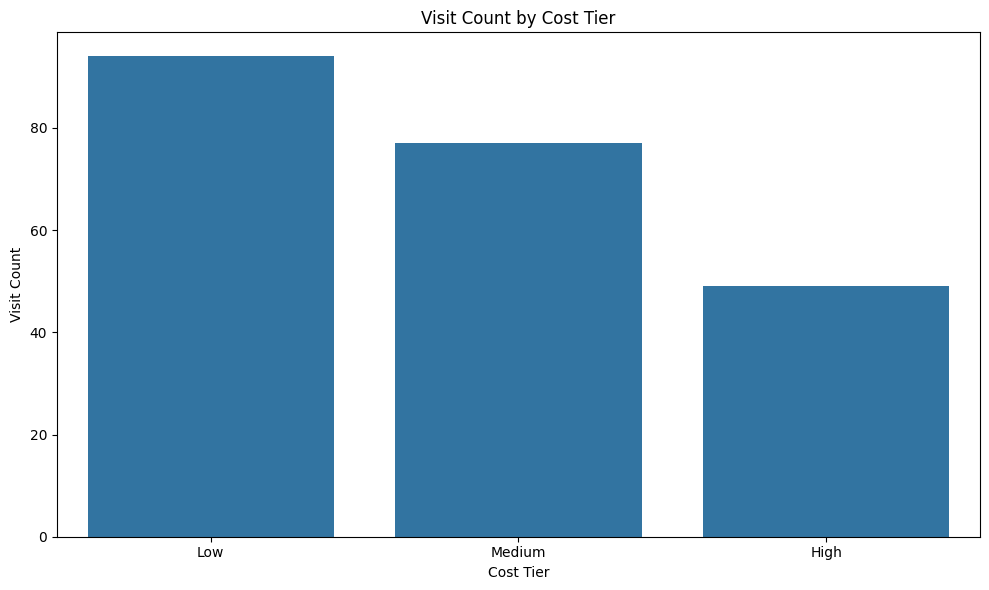

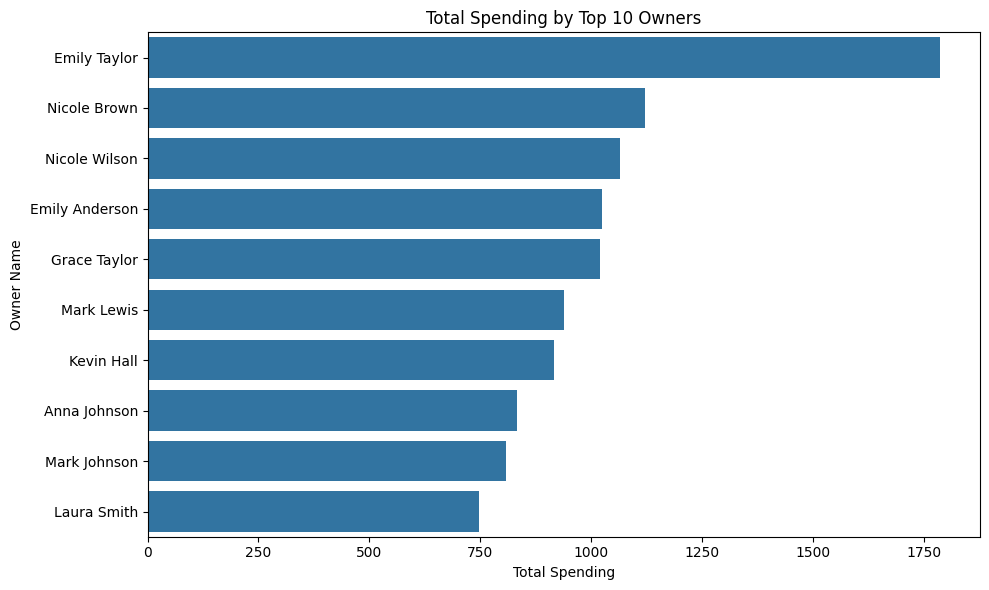

In [ ]:
# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Chart 1: visit count by cost tier (bar)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='price_tier', y='visit_count', data=price_tier, ax=ax)
ax.set_title('Visit Count by Cost Tier')
ax.set_xlabel('Cost Tier')
ax.set_ylabel('Visit Count')
plt.tight_layout()
plt.show()

# Chart 2: total spending by the top 10 owners (bar)

owners_total_cost = duckdb.sql("""
    SELECT 
        o.owner_id,
        o.owner_name,
        SUM(v.cost) as total_cost
    FROM owners o
    JOIN pets p ON o.owner_id = p.owner_id
    JOIN visits v ON p.pet_id = v.pet_id
    GROUP BY o.owner_id, o.owner_name
    ORDER BY total_cost DESC
    LIMIT 10
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x='total_cost', y='owner_name', data=owners_total_cost, ax=ax)
ax.set_title('Total Spending by Top 10 Owners')
ax.set_xlabel('Total Spending')
ax.set_ylabel('Owner Name')
plt.tight_layout()
plt.show()

---
# 💼 Business Insights
**What did I discover?**

- Emily Taylor spent the most (**$1,788**), about **$670** more than the next owner.
  (Emily Taylor가 가장 많이 지출했고($1,788) 다음 보호자보다 약 $670 많음)
- **28** pets visit more often than average. Sadie has the most visits (**8**).
  (평균보다 자주 오는 반려동물은 28마리. Sadie가 가장 많음(8회))
- Of 220 visits, **94** cost less than $50 and **49** cost more than $150.
  (220건 중 94건은 $50 미만이고 49건은 $150 초과)
  

---
# 🎯 Business Recommendation
**If I were the Business Analyst...**

1. Treat Emily Taylor's household as a key client, because that one owner spent **$1,788**.
   (Emily Taylor 가구를 주요 고객으로 보기. 보호자 한 명이 $1,788을 지출했기 때문)
2. Keep a recall list for the **28** pets above the average visit count, starting with Sadie.
   (평균보다 자주 오는 28마리를 리콜 목록으로 두고, Sadie부터 보기)
3. Most visits are under $150 (**94** Low + **77** Medium). Keep routine pricing clear, and review the **49** high-cost visits separately.
   (대부분의 진료는 $150 이하(Low 94 + Medium 77). 일반 가격은 분명하게 두고, 고액 49건은 따로 보기)
   

---
# ❌ Mistakes
**What mistakes did I make today?**

- I used `visits_per_pet` in the subquery before that result existed. The average has to be computed from `visits` inside the subquery.
  (결과가 생기기 전에 서브쿼리에서 visits_per_pet을 씀. 평균은 서브쿼리 안에서 visits로 계산해야 함)
- I tried to `AVG(visit_count)` in the same `SELECT` as `COUNT(*)`. `visit_count` is not a column until the counts are grouped first.
  (COUNT(*)와 같은 SELECT에서 AVG(visit_count)를 씀. visit_count는 건수를 먼저 묶은 뒤에야 생기는 이름)
- After the join, `pet_id` was ambiguous, and `pet_name` and `age` were missing from `GROUP BY`.
  (JOIN 뒤에는 pet_id가 어느 테이블인지 불명확했고, pet_name과 age가 GROUP BY에 없었음)
  

---
# ✅ What I Learned
**Today's biggest lesson**

- A three-table `JOIN` follows the keys in order: owners to pets on `owner_id`, then pets to visits on `pet_id`.
  (세 테이블 JOIN은 키 순서대로 연결. owners와 pets는 owner_id, pets와 visits는 pet_id)
- A subquery that groups first can be used as the average to compare against. The outer query only keeps rows above that average.
  (먼저 그룹을 만든 서브쿼리의 평균과 비교할 수 있음. 바깥 쿼리는 그 평균보다 큰 행만 남김)
- `CASE WHEN` assigns each visit to one tier. The cuts here are <$50, $50–$150, and >$150.
  (CASE WHEN은 진료 한 건을 구간 하나에 넣음. 여기 기준은 $50 미만, $50–$150, $150 초과)
  

---
# 🧠 Reflection

**What was difficult?**
The subquery for pets above the average visit count.
(평균 방문 횟수보다 자주 온 반려동물을 구하는 서브쿼리)

**Why?**
The per-pet count and the average of those counts are two steps, and a name I had not created yet cannot be used in the same `SELECT`.
(반려동물별 건수와 그 건수의 평균은 두 단계이고, 아직 만들지 않은 이름은 같은 SELECT에서 쓸 수 없음)

**How did I solve it?**
Grouped `visits` by `pet_id` first, averaged those counts in a second subquery, then filtered with `WHERE`.
(visits를 pet_id로 먼저 묶고, 그 건수의 평균을 두 번째 서브쿼리에서 구한 다음 WHERE로 거름)

**What would I do differently next time?**
Write the inner count query and check it before adding the average comparison or the pet name columns.
(평균 비교나 이름 컬럼을 붙이기 전에, 안쪽 건수 쿼리부터 실행해서 확인하기)



---
# ⭐ Self Evaluation

**Understanding**  
★★★★★★☆☆☆☆  
`JOIN` and `CASE WHEN` are clear. The subquery needed several corrections.  
(JOIN과 CASE WHEN은 이해. 서브쿼리는 여러 번 수정이 필요했음)

**Confidence**  
★★★★★★☆☆☆☆  

**Difficulty**  
★★★★★★★☆☆☆  
Building the average in a subquery was the hardest.  
(서브쿼리로 평균을 만드는 것이 제일 어려웠음)

---
# 📌 Tomorrow
*Tomorrow I will learn:*

- Practice Day 23 — Visualization storytelling with Seaborn (Round 2/5)  
  (Seaborn으로 시각화 스토리텔링 복습)
  